## Exercise: Try Making Your Own Plot

Using any data that you looked at earlier this week, make a plot that visualizes some element of your analysis. We'll ask a few people to present their results when they're ready.

*Note: Matplotlib can take numpy arrays or pandas series and dataframes as inputs. In addition, pandas dataframes have [a built-in interface to automatically call matplotlib functions](https://pandas.pydata.org/pandas-docs/stable/user_guide/visualization.html). This can be a convenient way to visualize for exploratory analysis. However, it's less customizable, so it may not be suitable for making presentation-quality graphs.*

Text(0.5, 1.0, 'Average Total Stat by Pokedex Index Range')

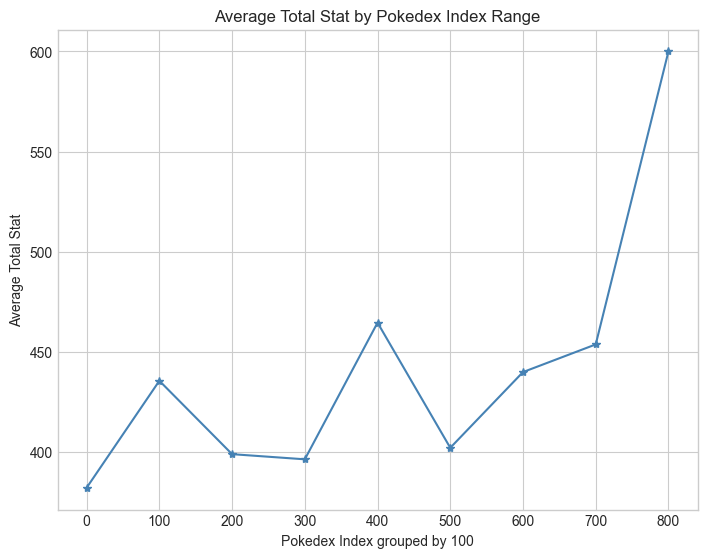

In [125]:
# Take the example of the pokedex.csv dataset from the last lesson Notebook 1 for the exercise 
# This exercise for example showing how the average `Total` stat changes across Pokedex index ranges.
# Students can get creative with this 


df = pd.read_csv("pokedex.csv")

# Bin Pokedex Index into groups of 100
df["Gen_bucket"] = (df["Index"] // 100) * 100

pokemon1 = df.groupby("Gen_bucket")["Total"].mean() #  We are grouping Pokemon by their Pokedex number range
pokemon1 = pokemon1.reset_index()

pokemon_figure = plt.figure()
ax = pokemon_figure.add_axes([0, 0, 1, 1])

x_data = pokemon1["Gen_bucket"]
y_data = pokemon1["Total"]

ax.plot(x_data, y_data, marker="*", color="steelblue")

# Add labels and title
ax.set_xlabel("Pokedex Index grouped by 100")
ax.set_ylabel("Average Total Stat")
ax.set_title("Average Total Stat by Pokedex Index Range")

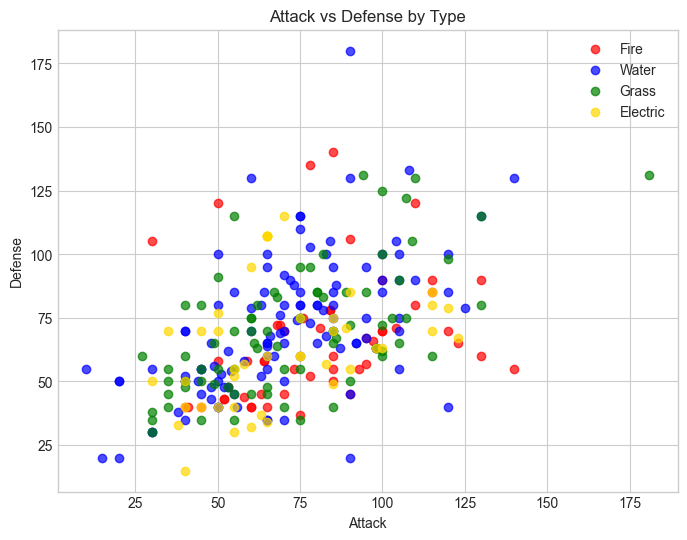

In [131]:
# Another example of Exercise: Try Making Your Own Plot
#In this one, I choose a few Pokémon types below and compare their `Atk` and `Def` values using a scatter plot.

df = pd.read_csv('pokedex.csv')

fig, ax = plt.subplots(figsize=(8,6))
types_to_plot = ['Fire', 'Water', 'Grass', 'Electric']
colors = {'Fire':'red', 'Water':'blue', 'Grass':'green', 'Electric':'gold'}

for t in types_to_plot:
    subset = df[df['Type I'] == t]
    ax.scatter(subset['Atk'], subset['Def'], label=t, color=colors[t], alpha=0.7)
#Add legend and label & title 
ax.set_xlabel('Attack')
ax.set_ylabel('Defense')
ax.set_title('Attack vs Defense by Type')
ax.legend()


## Exercise: Closest Distance

Let's put the `distance` function into action. Write a function that takes in a list of points and calculates the distance between the two closest points.

In [144]:
def getClosestDist(pointsList):
    """
    input: points_list, list of Points - a list of shapely Point objects
    output: dist, float - the distance between the two closest points in points_list
    """
    min_dist = None
    for i in range(len(pointsList)):
        for j in range(i + 1, len(pointsList)):
            current_dist = pointsList[i].distance(pointsList[j])
            if min_dist is None or current_dist < min_dist:
                min_dist = current_dist
    return min_dist

Hint for the optional challenge
This challenge builds on the previous function. Before, we only returned the closest distance. Now, we also want to return the positions of the two closest points in the list.

As the loop checks each pair of points, keep track of three things:

the smallest distance so far
the index of the first point
the index of the second point
The inner loop starts at i + 1 so we avoid comparing a point to itself or checking the same pair twice.

Remember: Python starts counting from 0, so the first point is at index 0.

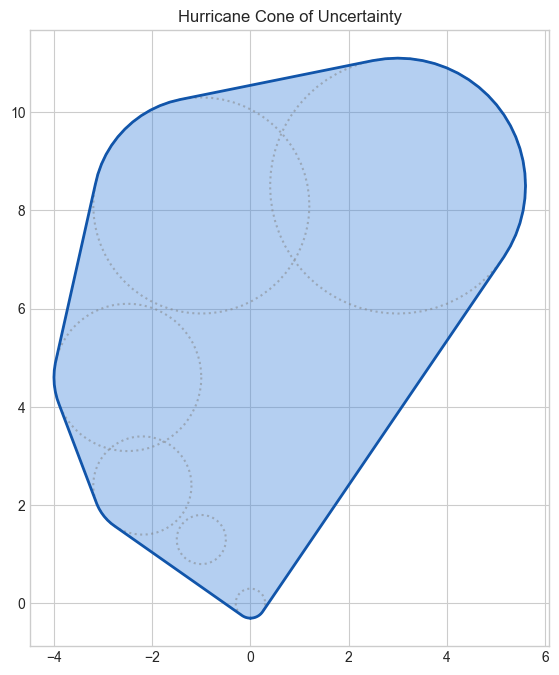

In [324]:
from shapely.geometry import Point, MultiPolygon
from shapely.ops import unary_union

forecast1 = Point(0,0).buffer(0.3)
forecast2 = Point(-1,1.3).buffer(0.5)
forecast3 = Point(-2.2,2.4).buffer(1)
forecast4 = Point(-2.5,4.6).buffer(1.5)
forecast5 = Point(-1,8.1).buffer(2.2)
forecast6 = Point(3,8.5).buffer(2.6)

circles = [forecast1, forecast2, forecast3, forecast4, forecast5, forecast6]
all_forecasts = MultiPolygon(circles)

merged = unary_union(all_forecasts)
cone = merged.convex_hull

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7,8))

# plot original circles lightly for reference
for c in circles:
    x, y = c.exterior.xy
    ax.plot(x, y, color='gray', linestyle=':', alpha=0.5)

# plot the final cone shape
x, y = cone.exterior.xy
ax.fill(x, y, color='#4488dd', alpha=0.4)
ax.plot(x, y, color='#1155aa', linewidth=2)

ax.set_aspect('equal')
ax.set_title('Hurricane Cone of Uncertainty')
plt.show()